# 📱 Android Permissions Dataset — Complete EDA, Report & Dashboard

Every step is one small cell. Run them from top to bottom.
| Step | What we do |
|---|---|
| 1 | Import libraries |
| 2 | Load the JSON file |
| 3 | Clean the data |
| 4 | Make a "one row per permission" table |
| 5 | Ask questions and draw charts (Q1 – Q10) |
| 6 | Build a dashboard picture |
| 7 | Build an HTML report |

Input : './data/googleplay-app-permission.json'
Output: `eda_output/` → `figures/*.png`, `report.html`, `dashboard.html`, `cleaned_playstore.json`

## About Dataset

- **`Description`**\
The **Android Permissions Dataset** contains information about permissions requested by Android applications. The dataset was obtained from Kaggle and provides structured data that can be used to analyze permission usage patterns across Android apps. You can download this dataset from the following [link](https://www.kaggle.com/datasets/gauthamp10/app-permissions-android/data).

- **`Context`**\
Android applications often require access to sensitive device resources such as the camera, microphone, contacts, storage, location, and network. Understanding the permissions requested by applications can provide valuable insights into app behavior, security, privacy, and potential risks. <br> This dataset provides an opportunity to explore how Android applications use different permissions and to identify patterns or relationships between applications and the resources they request.

- **`Content`**\
Each row represents an Android application and contains information related to the permissions requested by the application. The dataset can be explored to identify common permission patterns, relationships among permissions, and differences in permission requirements across applications.

Depending on the available attributes, the dataset may support analyses such as:
1. Frequency and distribution of Android permissions
2. Relationships between different permissions
3. Identification of commonly requested permission combinations
4. Application classification based on permission usage
5. Privacy and security-oriented exploratory analysis
  
- **`Acknowledgements`**\
The dataset is based on Android application and permission information collected for research and analytical purposes. The original dataset was obtained from Kaggle.

- **`Inspiration`**\
Android permissions provide an important window into how applications interact with device resources. This dataset offers opportunities to investigate permission usage patterns and develop data-driven approaches for understanding Android application behavior. <br> Potential applications include exploratory data analysis, application classification, permission-pattern mining, privacy analysis, and Android security research.

## Step 1 — Import libraries

In [1]:
import ast, re, base64
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- nice look for all charts ----
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
COLOR = "#6366F1"

Path("charts").mkdir(exist_ok=True)   # folder where charts are saved
notes = {}                            # one insight sentence per chart (used in the report)

## Step 2 — Load the data
The file has 2.3 million apps. Turning every permission into its own row gives ~25 million rows, which is too heavy for most laptops.

In [2]:
df = pd.read_json('./data/googleplay-app-permission.json')
print("Rows in file:", len(df))
df.head( )

Rows in file: 2292693


,appId,appName,allPermissions
0,com.weddingstagedecorations.linastudio,wedding stage decorations,"[{'permission': 'view network connections', 't..."
1,com.bestappsstickers.app.stickersgif_lovegif_R...,Romantic Animated Sticker 💖 for WhatsApp💖,[{'permission': 'read the contents of your USB...
2,com.google.android.apps.messaging,Messages,[{'permission': 'modify or delete the contents...
3,com.zoho.crm,Zoho CRM - Sales & Marketing,"[{'permission': 'directly call phone numbers',..."
4,tsc.multipurposemirror.com,Makeup Mirror And Phone Charger : Shop Today,"[{'permission': 'full network access', 'type':..."


In [3]:
# hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')

- Let's have a look on the shape of the dataset

In [4]:
df.shape

(2292693, 3)

Let's have a look on the columns and their data types using detailed info function

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2292693 entries, 0 to 2292692
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   appId           str   
 1   appName         str   
 2   allPermissions  object
dtypes: object(1), str(2)
memory usage: 52.5+ MB


# **Observations**
---
1. There are 2292693 rows and 3 columns in the dataset
2. The columns are of different data types
3. The columns in the datasets are:
   - `'appId', 'appName', 'allPermissions'`
4. There is one column which is of object data type but they should be of numeric data type, we will convert them later on in the notebook.
   - `'appId', 'appName'`

## Step 3 — Clean the data

In [7]:
# 1) remove duplicate apps
df = df.drop_duplicates("appId").reset_index(drop=True)

# 2) make sure allPermissions is always a list (sometimes it is text that looks like a list)
def to_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

df["allPermissions"] = df["allPermissions"].apply(to_list)

# 3) fill empty app names and count permissions per app
df["appName"] = df["appName"].fillna("")
df["n_perm"] = df["allPermissions"].apply(len)

n_apps = len(df)
print("Apps after cleaning:", n_apps)
print("Apps with no permissions:", (df.n_perm == 0).sum())

Apps after cleaning: 2292693
Apps with no permissions: 69066


## Step 4 — One row per permission
`explode` turns a list of permissions into separate rows.

In [8]:
perm = df[["appId", "allPermissions"]].explode("allPermissions").dropna()

perm["permission"] = perm["allPermissions"].apply(lambda d: d["permission"].lower())
perm["type"]       = perm["allPermissions"].apply(lambda d: d.get("type", "Unknown"))

perm = perm.drop(columns="allPermissions").drop_duplicates(["appId", "permission"])
print("Permission rows:", len(perm), "| Unique permissions:", perm.permission.nunique())
perm.head()

Permission rows: 15923426 | Unique permissions: 89


,appId,permission,type
0,com.weddingstagedecorations.linastudio,view network connections,Other
0,com.weddingstagedecorations.linastudio,full network access,Other
1,com.bestappsstickers.app.stickersgif_lovegif_R...,read the contents of your usb storage,Photos/Media/Files
1,com.bestappsstickers.app.stickersgif_lovegif_R...,modify or delete the contents of your usb storage,Photos/Media/Files
1,com.bestappsstickers.app.stickersgif_lovegif_R...,view network connections,Other


## Step 5 — Questions & charts

### Q1. How many permissions does an app ask for?

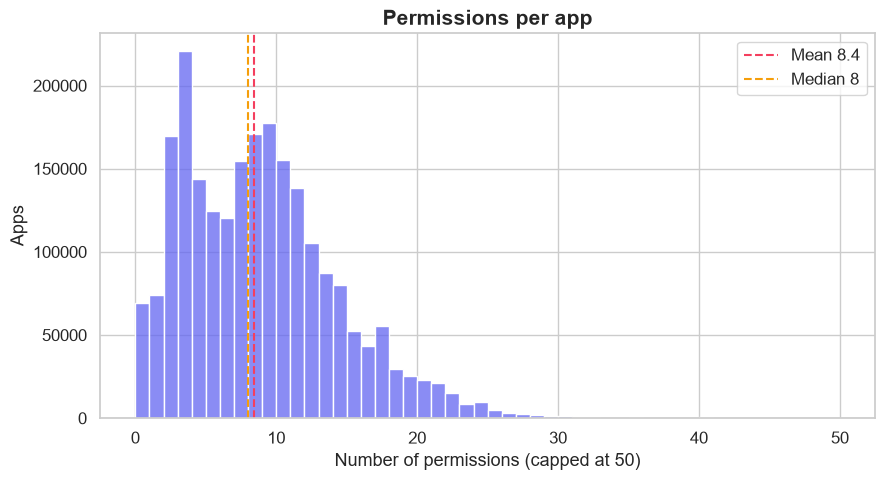

The typical app asks for 8 permissions; the top 5% ask for 19 or more.


In [9]:
sns.histplot(df.n_perm.clip(upper=50), bins=50, color=COLOR)
plt.axvline(df.n_perm.mean(),   color="#F43F5E", linestyle="--", label=f"Mean {df.n_perm.mean():.1f}")
plt.axvline(df.n_perm.median(), color="#F59E0B", linestyle="--", label=f"Median {df.n_perm.median():.0f}")
plt.title("Permissions per app")
plt.xlabel("Number of permissions (capped at 50)")
plt.ylabel("Apps")
plt.legend()

notes["perms_per_app"] = f"The typical app asks for {df.n_perm.median():.0f} permissions; the top 5% ask for {df.n_perm.quantile(.95):.0f} or more."
plt.savefig("charts/perms_per_app.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["perms_per_app"])

### Q2. Which permissions are requested most?

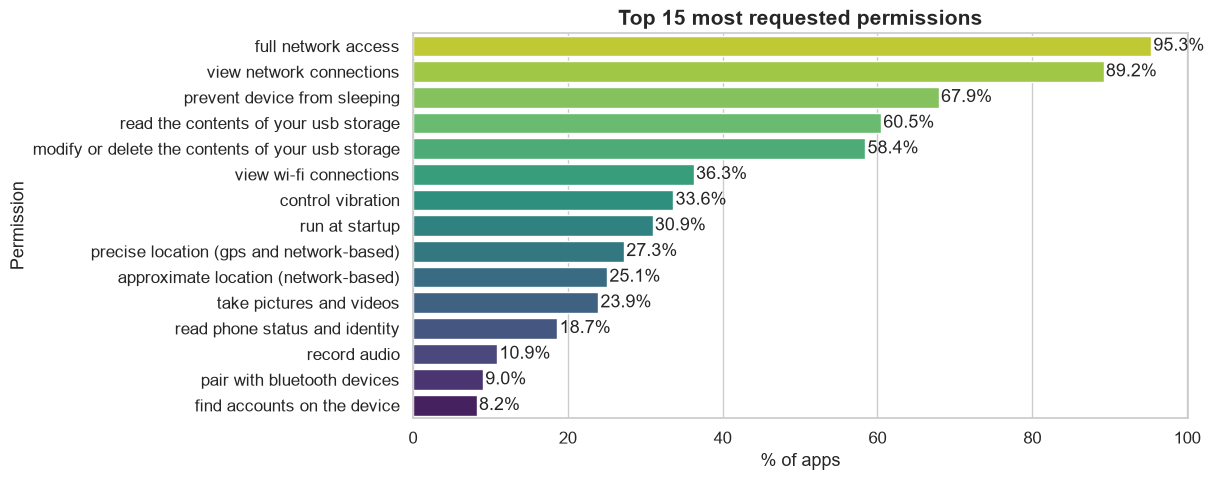

'full network access' is requested by 95.3% of all apps.


In [11]:
top_perms = perm.permission.value_counts().head(15) / n_apps * 100
top_perms.index = top_perms.index.str.slice(0, 50)

sns.barplot(x=top_perms.values, y=top_perms.index, hue=top_perms.index, palette="viridis_r", legend=False)
for i, v in enumerate(top_perms.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.title("Top 15 most requested permissions")
plt.xlabel("% of apps")
plt.ylabel("Permission")

notes["top_permissions"] = f"'{top_perms.index[0]}' is requested by {top_perms.iloc[0]:.1f}% of all apps."
plt.savefig("charts/top_permissions.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["top_permissions"])

### Q3. Which permission groups (`type`) are most common?

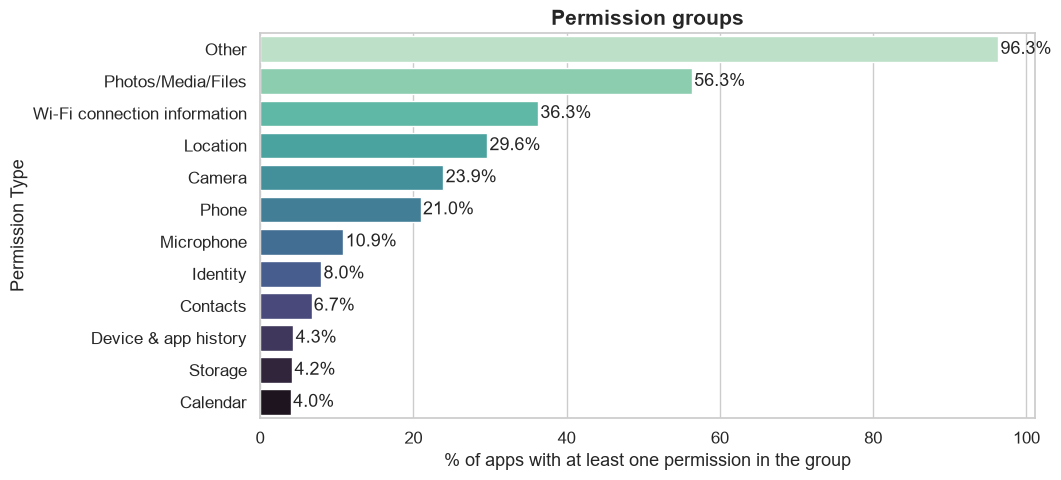

'Other' is the most common group (96.3% of apps).


In [14]:
by_type = perm.drop_duplicates(["appId", "type"]).type.value_counts().head(12) / n_apps * 100

sns.barplot(x=by_type.values, y=by_type.index, hue=by_type.index, palette="mako_r", legend=False)
for i, v in enumerate(by_type.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.title("Permission groups")
plt.xlabel("% of apps with at least one permission in the group")
plt.ylabel("Permission Type")

notes["types"] = f"'{by_type.index[0]}' is the most common group ({by_type.iloc[0]:.1f}% of apps)."
plt.savefig("charts/types.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["types"])

### Q4. How many apps ask for *sensitive* things?
We search the permission text for keywords (location, camera, microphone ...). Each app gets a True/False flag per group.
> The keywords are a simple guess — you can add or change them in `SENSITIVE`.

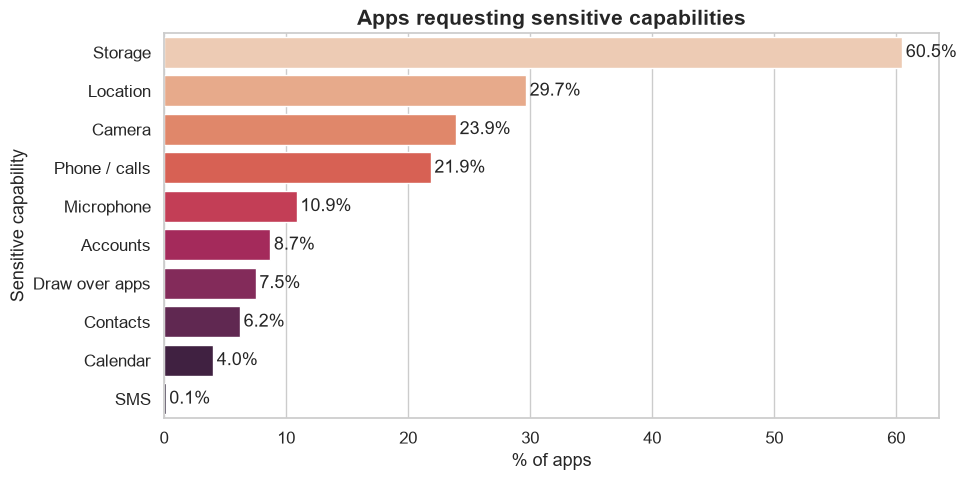

Storage is the most common sensitive capability (60.5% of apps).


In [16]:
SENSITIVE = {
    "Location":      "location|gps",
    "Camera":        "camera|take pictures",
    "Microphone":    "record audio|microphone",
    "Contacts":      "contacts",
    "SMS":           r"\bsms\b|text messages|mms",
    "Phone / calls": "call phone|directly call|call log|phone status",
    "Calendar":      "calendar",
    "Accounts":      "accounts",
    "Storage":       "storage",
    "Draw over apps":"draw over",
}

for name, pattern in SENSITIVE.items():
    apps_with_it = perm.loc[perm.permission.str.contains(pattern), "appId"].unique()
    df[name] = df.appId.isin(apps_with_it)

share = df[list(SENSITIVE)].mean().sort_values(ascending=False) * 100

sns.barplot(x=share.values, y=share.index, hue=share.index, palette="rocket_r", legend=False)
for i, v in enumerate(share.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.title("Apps requesting sensitive capabilities")
plt.xlabel("% of apps")
plt.ylabel("Sensitive capability")

notes["sensitive"] = f"{share.index[0]} is the most common sensitive capability ({share.iloc[0]:.1f}% of apps)."
plt.savefig("charts/sensitive.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["sensitive"])

### For Fast Execution, Use REGEX

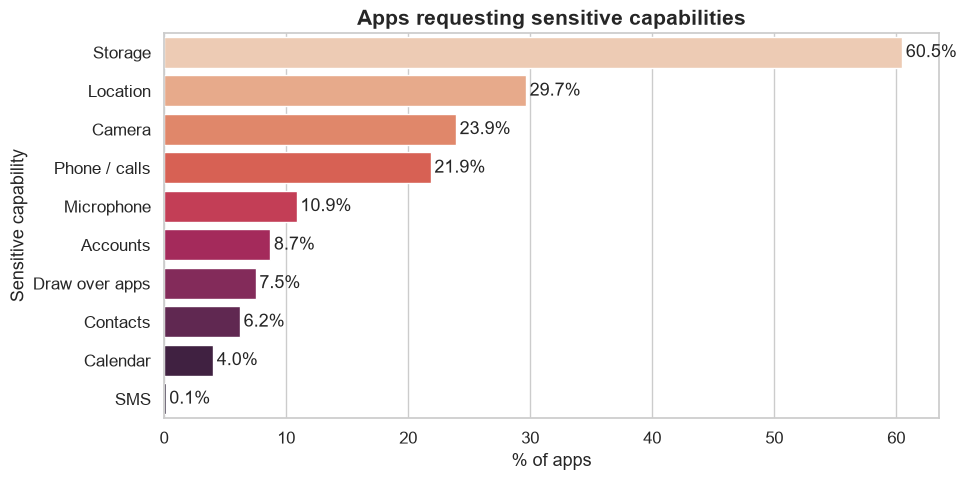

Storage is the most common sensitive capability (60.5% of apps).


In [22]:
import re

# compile once, case-insensitive
# original was case-sensitive so missed ACCESS_FINE_LOCATION, etc.
RX = {k: re.compile(v, re.IGNORECASE) for k, v in SENSITIVE.items()}

# 1. unique permissions only: ~200 not ~1M
uniq = perm["permission"].dropna().unique()

# permission -> 10 bools, only 200*10 regex tests
lookup = pd.DataFrame(
    [[bool(RX[c].search(p)) for c in SENSITIVE] for p in uniq],
    index=pd.Index(uniq, name="permission"),
    columns=list(SENSITIVE)
).reset_index()

# 2. one hash-join + one groupby instead of 10 regex scans + 10 isin
tmp = perm[["appId", "permission"]].merge(lookup, on="permission", how="left")
tmp[list(SENSITIVE)] = tmp[list(SENSITIVE)].fillna(False)
app_mat = tmp.groupby("appId", sort=False)[list(SENSITIVE)].max()

# 3. assign all columns at once - avoids fragmented df[name]= in loop
df = df.drop(columns=list(SENSITIVE), errors="ignore")
df = df.join(app_mat, on="appId")
df[list(SENSITIVE)] = df[list(SENSITIVE)].fillna(False).astype(bool)

share = df[list(SENSITIVE)].mean().sort_values(ascending=False) * 100

sns.barplot(x=share.values, y=share.index, hue=share.index, palette="rocket_r", legend=False)
for i, v in enumerate(share.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.title("Apps requesting sensitive capabilities")
plt.xlabel("% of apps")
plt.ylabel("Sensitive capability")

notes["sensitive"] = f"{share.index[0]} is the most common sensitive capability ({share.iloc[0]:.1f}% of apps)."
plt.savefig("charts/sensitive.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["sensitive"])

### Q5. Risk score — how risky is each app?
Simple rule: **risk = how many sensitive groups the app uses** (0 to 10).

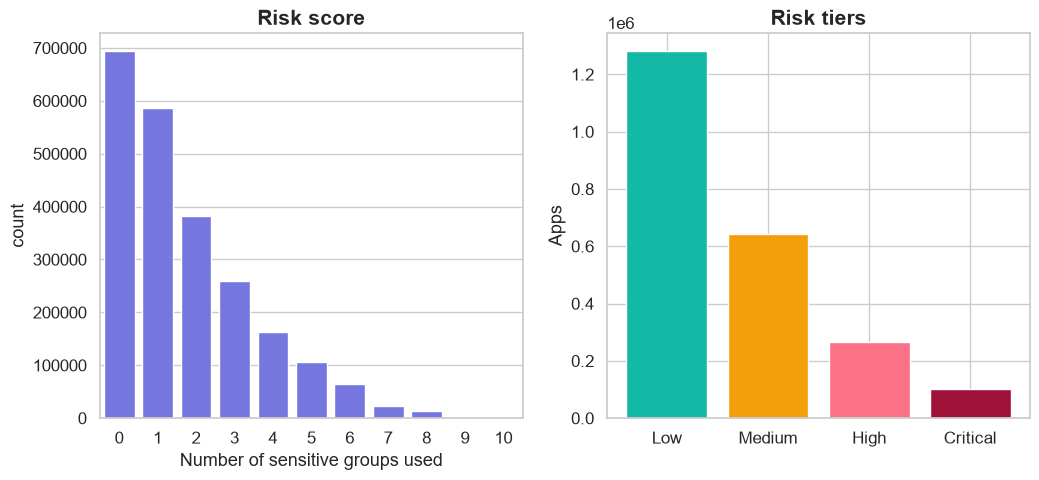

16.1% of apps are in the High or Critical tier. Average risk score is 1.73.


In [17]:
df["risk"] = df[list(SENSITIVE)].sum(axis=1)
df["tier"] = pd.cut(df.risk, bins=[-1, 1, 3, 5, 10], labels=["Low", "Medium", "High", "Critical"])
tier_counts = df.tier.value_counts().reindex(["Low", "Medium", "High", "Critical"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="risk", data=df, color=COLOR, ax=axes[0])
axes[0].set_title("Risk score")
axes[0].set_xlabel("Number of sensitive groups used")

axes[1].bar(tier_counts.index, tier_counts.values, color=["#14B8A6", "#F59E0B", "#FB7185", "#9F1239"])
axes[1].set_title("Risk tiers")
axes[1].set_ylabel("Apps")

high = (tier_counts["High"] + tier_counts["Critical"]) / n_apps * 100
notes["risk"] = f"{high:.1f}% of apps are in the High or Critical tier. Average risk score is {df.risk.mean():.2f}."
plt.savefig("charts/risk.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["risk"])

### Q6. Which apps ask for the most permissions?

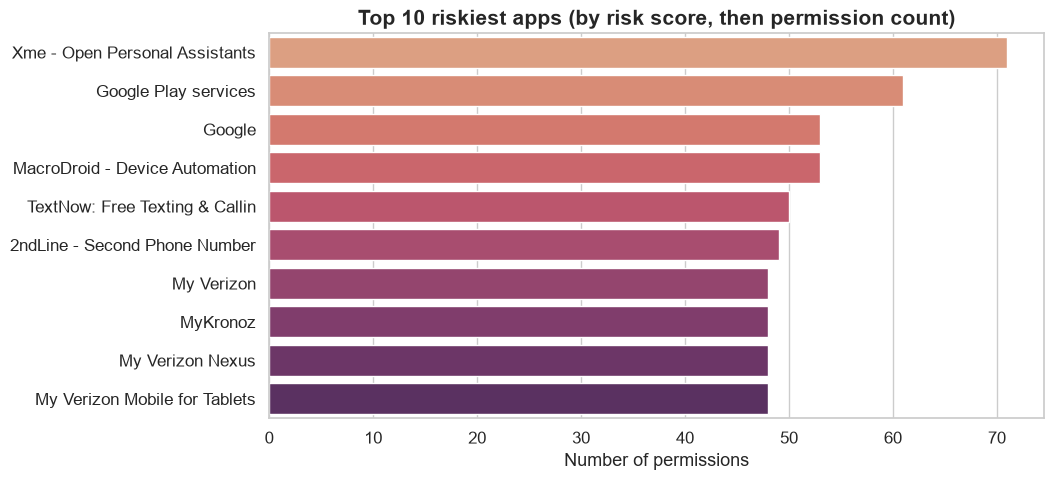

The riskiest app asks for 71 permissions and touches 10 sensitive groups.


In [18]:
riskiest = df.sort_values(["risk", "n_perm"], ascending=False).head(10).copy()
# remove emojis / special characters so labels draw correctly
riskiest["label"] = riskiest.appName.apply(lambda s: re.sub(r"[^\x00-\x7F]+", "", s).strip()[:30] or "(no name)")

sns.barplot(x="n_perm", y="label", data=riskiest, hue="label", palette="flare", legend=False)
plt.title("Top 10 riskiest apps (by risk score, then permission count)")
plt.xlabel("Number of permissions")
plt.ylabel("")

notes["riskiest"] = f"The riskiest app asks for {riskiest.n_perm.iloc[0]} permissions and touches {riskiest.risk.iloc[0]} sensitive groups."
plt.savefig("charts/riskiest.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["riskiest"])

### Q7. Which permissions are requested together?
We take the 10 most common permissions and check how strongly they move together (correlation).

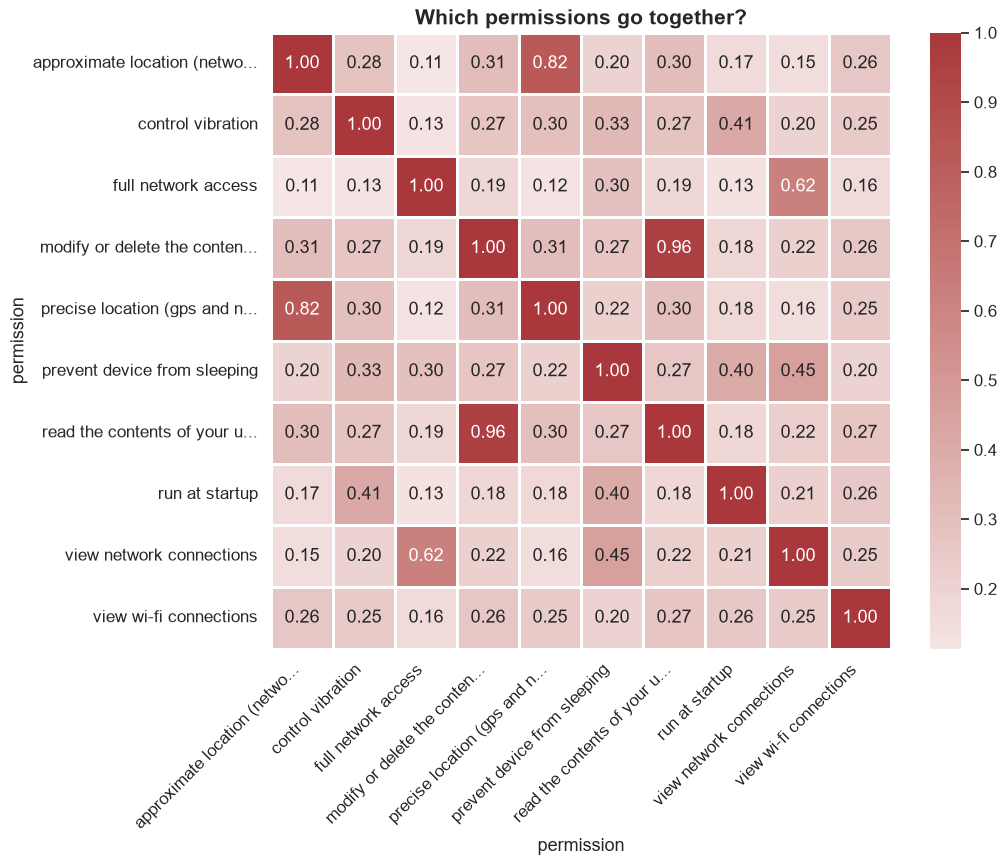

Strongest link: 'modify or delete the contents of your usb storage' and 'read the contents of your usb storage' (correlation 0.96).


In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 most frequently requested permissions
top10 = perm["permission"].value_counts().head(10).index

# Keep only relevant rows and ensure one row per app-permission combination
subset = (
    perm.loc[
        perm["permission"].isin(top10),
        ["appId", "permission"]
    ]
    .dropna()
    .drop_duplicates(["appId", "permission"])
)

# Binary app × permission matrix: 1 means the app requests the permission
table = (
    subset.assign(has_permission=np.uint8(1))
    .pivot(
        index="appId",
        columns="permission",
        values="has_permission"
    )
    .fillna(0)
    .astype(np.uint8)
)

# Include every app from df, including apps that have none of the top-10 permissions
table = table.reindex(
    pd.Index(df["appId"].drop_duplicates(), name="appId"),
    fill_value=0
)

# Compute correlations before shortening labels
corr = table.corr()

# Avoid duplicate column names caused by truncating strings to 30 characters
def short_label(label, max_len=30):
    return label if len(label) <= max_len else label[:max_len - 3] + "..."

labels = [short_label(str(col)) for col in corr.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=1,
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Which permissions go together?")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Ignore diagonal self-correlations
pairs = corr.where(~np.eye(len(corr), dtype=bool)).stack()

if not pairs.empty:
    a, b = pairs.abs().idxmax()
    notes["cooccurrence"] = (
        f"Strongest link: '{a}' and '{b}' "
        f"(correlation {pairs.loc[(a, b)]:.2f})."
    )
else:
    notes["cooccurrence"] = "No valid permission-pair correlations were available."

plt.savefig("charts/cooccurrence.png", bbox_inches="tight", dpi=150)
plt.show()

print(notes["cooccurrence"])

### Q8. Do apps with more permissions have a higher risk?

- The only problem I see here is the `+` sign in the values, let's remove them and convert the column into numeric data type.

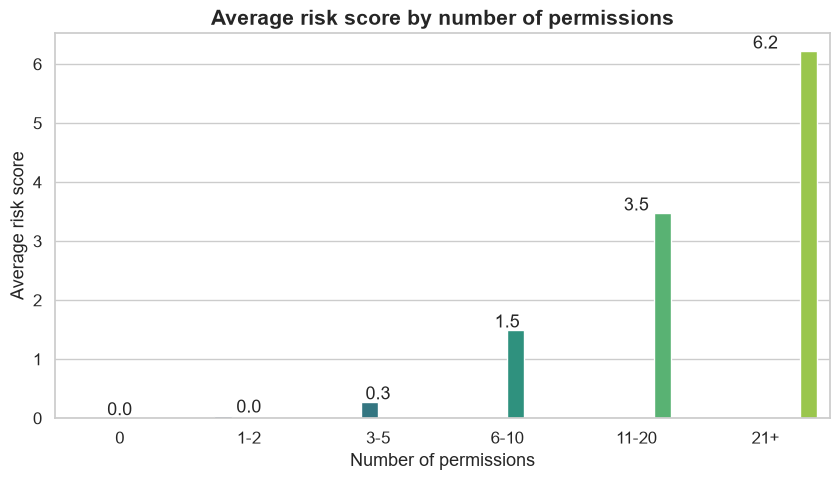

Correlation between permission count and risk is 0.92.


In [24]:
df["perm_group"] = pd.cut(df.n_perm, bins=[-1, 0, 2, 5, 10, 20, 9999], labels=["0", "1-2", "3-5", "6-10", "11-20", "21+"])
avg_risk = df.groupby("perm_group", observed=True).risk.mean()

sns.barplot(x=avg_risk.index, y=avg_risk.values, hue=avg_risk.index, palette="viridis", legend=False)
for i, v in enumerate(avg_risk.values):
    plt.text(i, v + 0.05, f"{v:.1f}", ha="center")
plt.title("Average risk score by number of permissions")
plt.xlabel("Number of permissions")
plt.ylabel("Average risk score")

corr_value = df.n_perm.corr(df.risk, method="spearman")
notes["volume_vs_risk"] = f"Correlation between permission count and risk is {corr_value:.2f}."
plt.savefig("charts/volume_vs_risk.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["volume_vs_risk"])

### Q9. Do some kinds of apps (by name) ask for more? (e.g. flashlight, wallpaper)

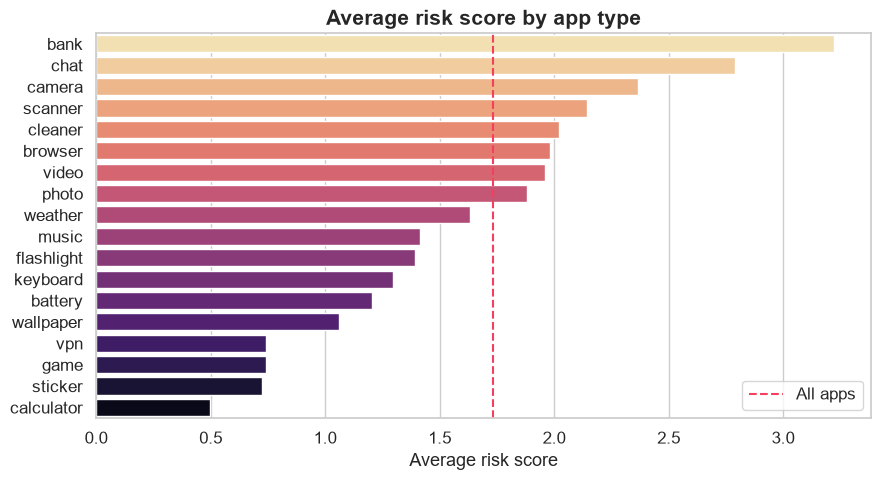

Apps with 'bank' in the name have the highest average risk (3.22 vs 1.73 for all apps).


In [25]:
THEMES = ["flashlight", "wallpaper", "vpn", "game", "camera", "keyboard", "cleaner", "weather",
          "chat", "photo", "music", "battery", "calculator", "scanner", "bank", "browser", "sticker", "video"]

rows = []
for word in THEMES:
    mask = df.appName.str.lower().str.contains(word)
    if mask.sum() >= 30:                                   # need enough apps to be fair
        rows.append((word, mask.sum(), df.risk[mask].mean()))

themes = pd.DataFrame(rows, columns=["theme", "apps", "avg_risk"]).sort_values("avg_risk", ascending=False)

sns.barplot(x="avg_risk", y="theme", data=themes, hue="theme", palette="magma_r", legend=False)
plt.axvline(df.risk.mean(), color="#F43F5E", linestyle="--", label="All apps")
plt.title("Average risk score by app type")
plt.xlabel("Average risk score")
plt.ylabel("")
plt.legend()

notes["themes"] = f"Apps with '{themes.theme.iloc[0]}' in the name have the highest average risk ({themes.avg_risk.iloc[0]:.2f} vs {df.risk.mean():.2f} for all apps)."
plt.savefig("charts/themes.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["themes"])

### Q10. Which publishers have the most apps, and how risky are they?
Publisher = the first two parts of the appId (for example `com.google`).

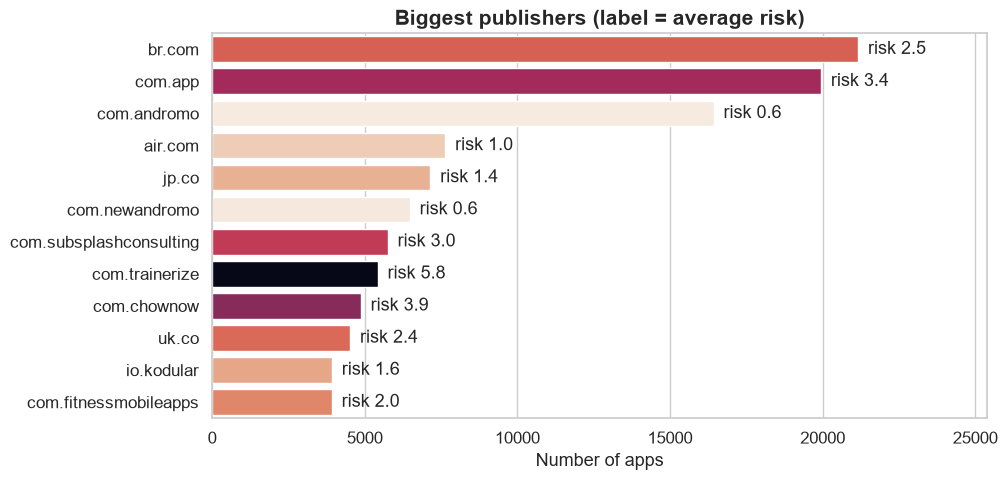

'br.com' has the most apps (21,159); its average risk is 2.5.


In [26]:
df["publisher"] = df.appId.str.split(".").str[:2].str.join(".")

pubs = df.groupby("publisher").agg(apps=("appId", "size"), avg_risk=("risk", "mean")).nlargest(12, "apps").reset_index()

sns.barplot(x="apps", y="publisher", data=pubs, hue="avg_risk", palette="rocket_r", legend=False, dodge=False)
for i, r in pubs.iterrows():
    plt.text(r.apps, i, f"  risk {r.avg_risk:.1f}", va="center")
plt.title("Biggest publishers (label = average risk)")
plt.xlabel("Number of apps")
plt.ylabel("")
plt.xlim(0, pubs.apps.max() * 1.2)

notes["publishers"] = f"'{pubs.publisher.iloc[0]}' has the most apps ({pubs.apps.iloc[0]:,}); its average risk is {pubs.avg_risk.iloc[0]:.1f}."
plt.savefig("charts/publishers.png", bbox_inches="tight", dpi=150)
plt.show()
print(notes["publishers"])

## Step 6 — Dashboard
One picture that shows the most important charts together, plus a small HTML page around it.

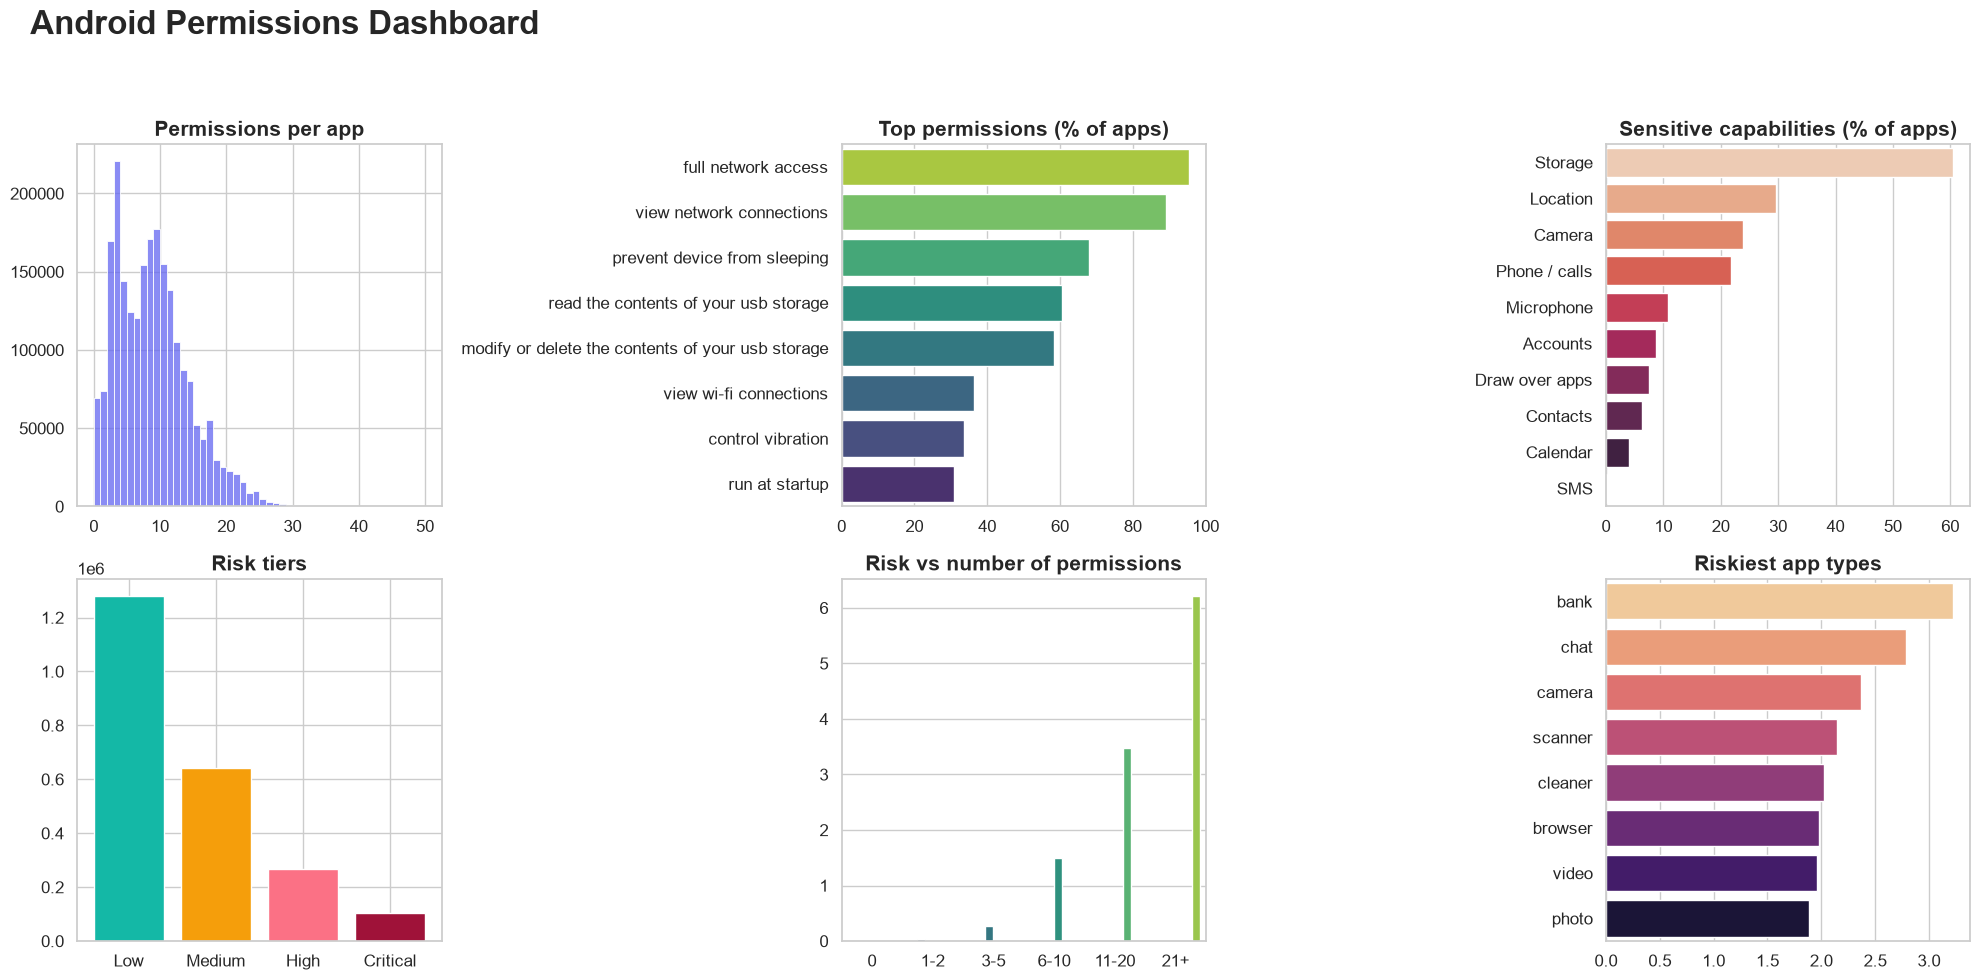

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Android Permissions Dashboard", fontsize=24, fontweight="bold", x=0.02, ha="left")

sns.histplot(df.n_perm.clip(upper=50), bins=50, color=COLOR, ax=axes[0, 0])
axes[0, 0].set_title("Permissions per app")

sns.barplot(x=top_perms.values[:8], y=top_perms.index[:8], hue=top_perms.index[:8], palette="viridis_r", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Top permissions (% of apps)")

sns.barplot(x=share.values, y=share.index, hue=share.index, palette="rocket_r", legend=False, ax=axes[0, 2])
axes[0, 2].set_title("Sensitive capabilities (% of apps)")

axes[1, 0].bar(tier_counts.index, tier_counts.values, color=["#14B8A6", "#F59E0B", "#FB7185", "#9F1239"])
axes[1, 0].set_title("Risk tiers")

sns.barplot(x=avg_risk.index, y=avg_risk.values, hue=avg_risk.index, palette="viridis", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Risk vs number of permissions")

sns.barplot(x="avg_risk", y="theme", data=themes.head(8), hue="theme", palette="magma_r", legend=False, ax=axes[1, 2])
axes[1, 2].set_title("Riskiest app types")

for ax in axes.flat:
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("charts/dashboard.png", bbox_inches="tight", dpi=110)
plt.show()

In [28]:
kpis = [("Apps analysed", f"{n_apps:,}"),
        ("Unique permissions", f"{perm.permission.nunique():,}"),
        ("Avg permissions / app", f"{df.n_perm.mean():.1f}"),
        ("Avg risk score", f"{df.risk.mean():.2f}"),
        ("High / Critical apps", f"{high:.1f}%")]

img = base64.b64encode(open("charts/dashboard.png", "rb").read()).decode()
cards = "".join(f"<div class='kpi'><small>{a}</small><b>{b}</b></div>" for a, b in kpis)

page = f"""<html><head><meta charset='utf-8'><style>
body{{margin:0;background:#0B1120;color:#E6ECF8;font-family:Segoe UI,Arial,sans-serif;padding:24px}}
h1{{margin:0 0 16px}} .row{{display:flex;gap:14px;flex-wrap:wrap;margin-bottom:18px}}
.kpi{{background:#131C31;border:1px solid #22304D;border-radius:14px;padding:14px 20px;min-width:170px}}
.kpi small{{color:#8A9BBD;text-transform:uppercase;font-size:11px}} .kpi b{{display:block;font-size:26px}}
img{{width:100%;background:white;border-radius:14px}}</style></head><body>
<h1>Android Permissions Dashboard</h1><div class='row'>{cards}</div>
<img src='data:image/png;base64,{img}'></body></html>"""

open("dashboard.html", "w", encoding="utf-8").write(page)
print("Saved dashboard.html")

Saved dashboard.html


## Step 7 — HTML report

In [29]:
sections = [("perms_per_app", "Q1. Permissions per app"),
            ("top_permissions", "Q2. Most requested permissions"),
            ("types", "Q3. Permission groups"),
            ("sensitive", "Q4. Sensitive capabilities"),
            ("risk", "Q5. Risk score and tiers"),
            ("riskiest", "Q6. Riskiest apps"),
            ("cooccurrence", "Q7. Permissions requested together"),
            ("volume_vs_risk", "Q8. More permissions = more risk?"),
            ("themes", "Q9. App types"),
            ("publishers", "Q10. Publishers")]

summary = "".join(f"<li>{notes[k]}</li>" for k, _ in sections)
report = f"""<html><head><meta charset='utf-8'><style>
body{{font-family:Segoe UI,Arial,sans-serif;max-width:900px;margin:auto;padding:24px;background:#F1F5F9;color:#0F172A;line-height:1.6}}
h1{{color:#4F46E5}} h2{{margin-top:34px}} img{{width:100%;border-radius:10px;background:white}}
.row{{display:flex;gap:12px;flex-wrap:wrap}} .kpi{{background:white;border-radius:12px;padding:12px 18px}}
.kpi small{{color:#64748B;text-transform:uppercase;font-size:11px}} .kpi b{{display:block;font-size:24px}}
.tip{{background:#EEF2FF;border-left:4px solid #6366F1;padding:10px 14px;border-radius:6px}}</style></head><body>
<h1>Android Permissions - EDA Report</h1><div class='row'>{cards}</div>
<h2>Summary of findings</h2><ul>{summary}</ul>"""

for key, title in sections:
    img = base64.b64encode(open(f"charts/{key}.png", "rb").read()).decode()
    report += f"<h2>{title}</h2><img src='data:image/png;base64,{img}'><p class='tip'>💡 {notes[key]}</p>"

report += "<p style='color:#64748B'>Note: the risk score is a simple keyword-based estimate, not a security audit.</p></body></html>"
open("report.html", "w", encoding="utf-8").write(report)
print("Saved report.html")

Saved report.html
